<a href="https://colab.research.google.com/github/JadoHR/customer_segmentation/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛍️ Customer Segmentation — Indonesian E-Commerce

This project analyzes customer behavior for an Indonesian e-commerce platform using **data mining and clustering techniques** to identify distinct customer segments.

## Methods
- **RFM Analysis** – evaluates customers based on Recency, Frequency, and Monetary value.
- **K-Means Clustering** – groups customers into behavioral segments.
- **Hierarchical Clustering** – explores cluster structure using dendrogram analysis.
- **PCA** – reduces dimensionality for 2D visualization of customer groups.

## Dataset
The dataset contains **100 customers from major Indonesian cities**, including purchase frequency, spending behavior, and recency metrics.

## Objective
Identify meaningful customer segments and generate **data-driven insights for targeted marketing strategies**.

## 1. Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('/content/indonesia_customers.csv')
print(f'Total customers : {len(df)}')
print(f'Columns         : {list(df.columns)}')
df.head()

Total customers : 100
Columns         : ['customer_id', 'city', 'province', 'island', 'age', 'gender', 'monthly_income_million_idr', 'monthly_spending_million_idr', 'shopping_frequency_per_month', 'favorite_product_category', 'shopping_channel', 'loyalty_score', 'year_joined', 'recency_days']


,customer_id,city,province,island,age,gender,monthly_income_million_idr,monthly_spending_million_idr,shopping_frequency_per_month,favorite_product_category,shopping_channel,loyalty_score,year_joined,recency_days
0,C001,Jakarta,DKI Jakarta,Java,28,Female,8.5,4.2,12,Fashion,Online,85,2020,5
1,C002,Surabaya,East Java,Java,35,Male,12.0,3.1,6,Electronics,Online,72,2019,14
2,C003,Bandung,West Java,Java,22,Female,4.5,3.8,20,Fashion,Online,91,2021,2
3,C004,Medan,North Sumatra,Sumatra,45,Male,15.0,5.5,4,Food & Grocery,Offline,65,2018,30
4,C005,Semarang,Central Java,Java,31,Female,7.0,2.9,10,Beauty & Skincare,Online,78,2020,7


## 2. Exploratory Data Analysis

=== DESCRIPTIVE STATISTICS ===
          age  monthly_income_million_idr  monthly_spending_million_idr  \
count  100.00                      100.00                         100.0   
mean    33.70                       12.73                           5.7   
std      9.84                       11.75                           4.9   
min     18.00                        2.00                           1.8   
25%     26.00                        6.72                           3.1   
50%     32.00                        9.25                           4.0   
75%     40.00                       14.00                           5.8   
max     62.00                       75.00                          30.0   

       shopping_frequency_per_month  loyalty_score  recency_days  
count                        100.00         100.00        100.00  
mean                           9.48          76.92         17.15  
std                            5.79          12.36         14.83  
min                      

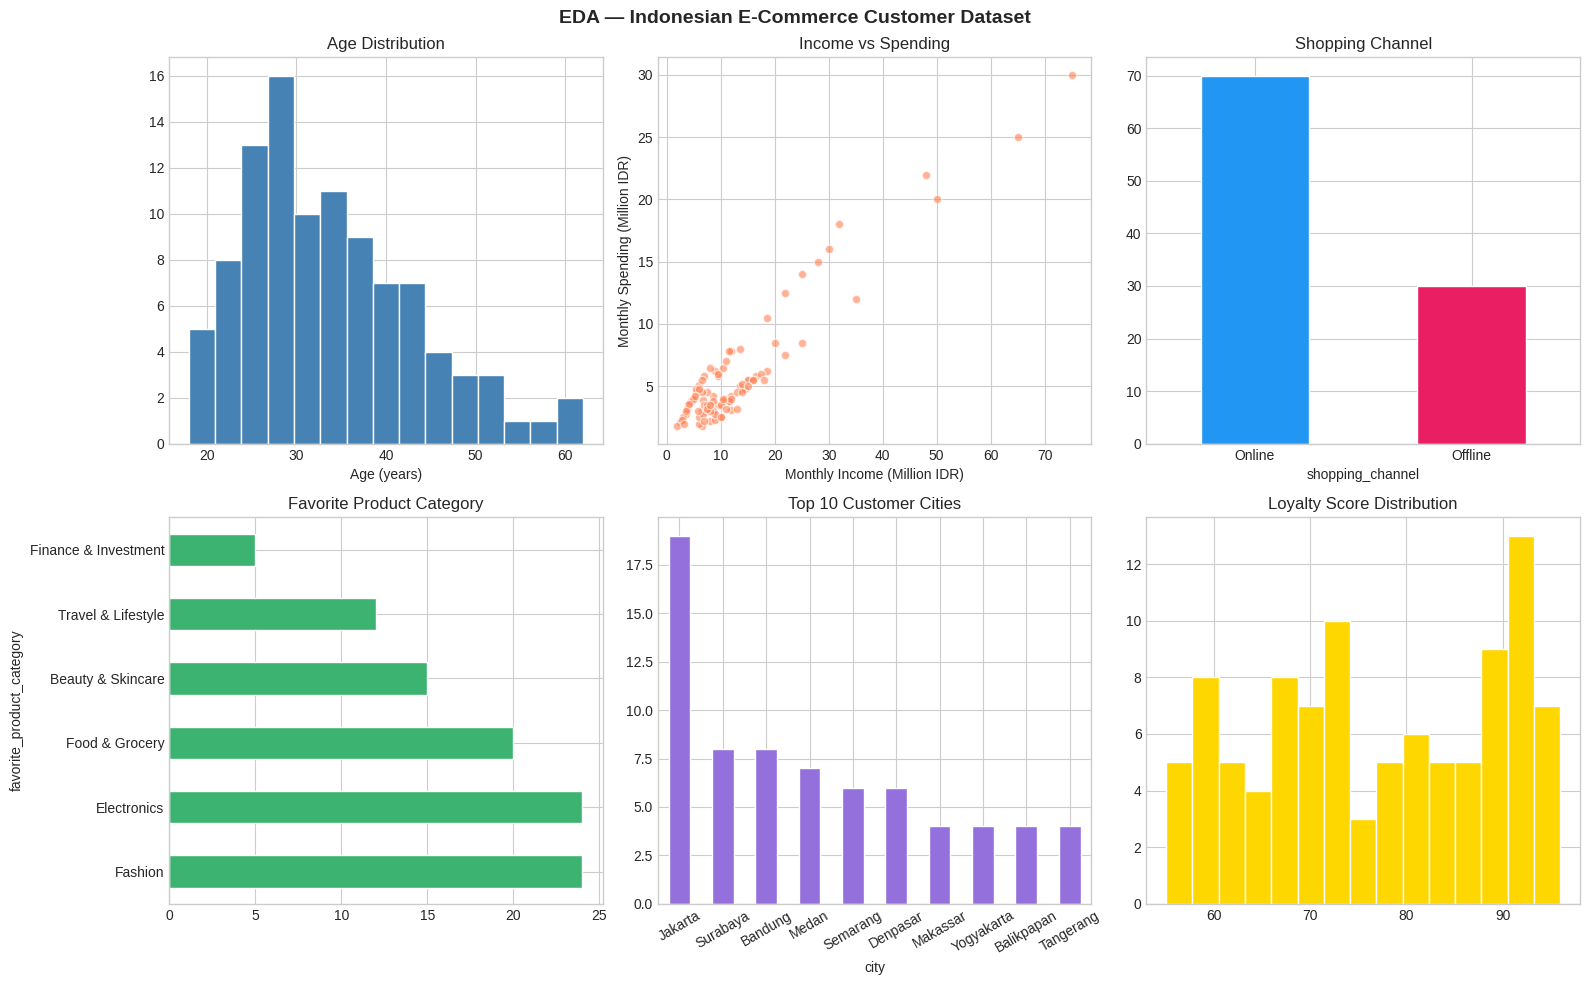

In [ ]:
print('=== DESCRIPTIVE STATISTICS ===')
print(df[['age', 'monthly_income_million_idr', 'monthly_spending_million_idr',
          'shopping_frequency_per_month', 'loyalty_score', 'recency_days']].describe().round(2))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Indonesian E-Commerce Customer Dataset', fontsize=14, fontweight='bold')

df['age'].hist(ax=axes[0, 0], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age (years)')

axes[0, 1].scatter(df['monthly_income_million_idr'], df['monthly_spending_million_idr'],
                   alpha=0.6, color='coral', edgecolors='white')
axes[0, 1].set_xlabel('Monthly Income (Million IDR)')
axes[0, 1].set_ylabel('Monthly Spending (Million IDR)')
axes[0, 1].set_title('Income vs Spending')

df['shopping_channel'].value_counts().plot(kind='bar', ax=axes[0, 2],
    color=['#2196F3', '#E91E63'], edgecolor='white')
axes[0, 2].set_title('Shopping Channel')
axes[0, 2].tick_params(axis='x', rotation=0)

df['favorite_product_category'].value_counts().plot(kind='barh', ax=axes[1, 0],
    color='mediumseagreen', edgecolor='white')
axes[1, 0].set_title('Favorite Product Category')

df['city'].value_counts().head(10).plot(kind='bar', ax=axes[1, 1],
    color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Top 10 Customer Cities')
axes[1, 1].tick_params(axis='x', rotation=30)

df['loyalty_score'].hist(ax=axes[1, 2], bins=15, color='gold', edgecolor='white')
axes[1, 2].set_title('Loyalty Score Distribution')

plt.tight_layout()
plt.savefig('eda_customers.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. RFM Analysis (Recency, Frequency, Monetary)

=== RFM SEGMENT DISTRIBUTION ===
Segment
At Risk      28
Loyal        24
Potential    23
Champions    14
Lost         11


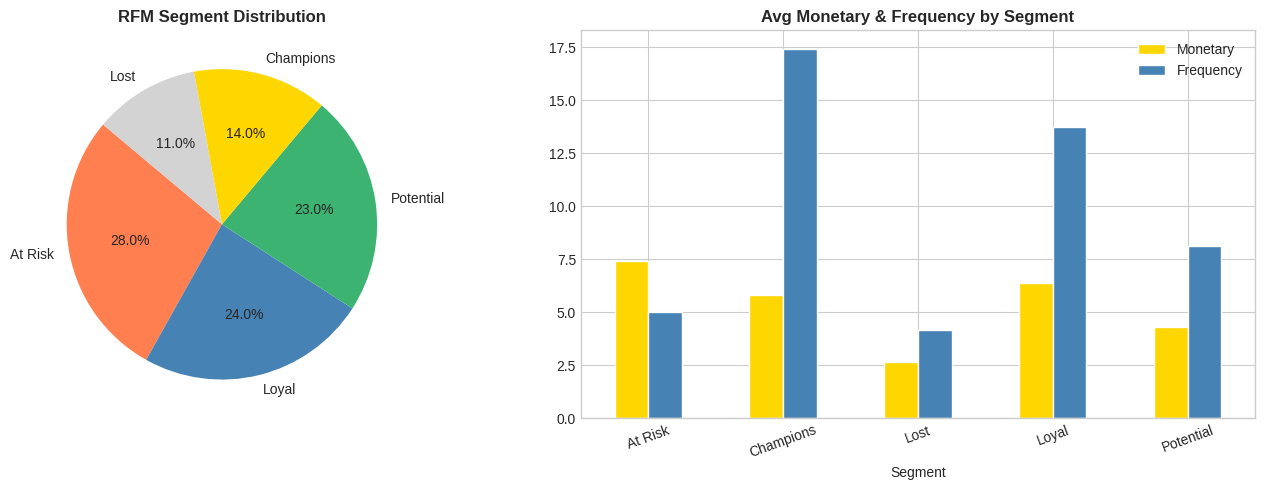

In [ ]:
rfm = df[['customer_id', 'recency_days', 'shopping_frequency_per_month', 'monthly_spending_million_idr']].copy()
rfm.columns = ['customer_id', 'Recency', 'Frequency', 'Monetary']

# Score 1–4 (4 = best)
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1, 2, 3, 4]).astype(int)
rfm['RFM_Score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_segment(score):
    if score >= 11: return 'Champions'
    elif score >= 9: return 'Loyal'
    elif score >= 7: return 'Potential'
    elif score >= 5: return 'At Risk'
    else:            return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(rfm_segment)
print('=== RFM SEGMENT DISTRIBUTION ===')
print(rfm['Segment'].value_counts().to_string())

segment_colors = {'Champions':'gold', 'Loyal':'steelblue', 'Potential':'mediumseagreen',
                  'At Risk':'coral', 'Lost':'lightgray'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = rfm['Segment'].value_counts()
axes[0].pie(counts, labels=counts.index,
            colors=[segment_colors[s] for s in counts.index],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[0].set_title('RFM Segment Distribution', fontweight='bold')

rfm.groupby('Segment')[['Monetary', 'Frequency']].mean().plot(
    kind='bar', ax=axes[1], color=['gold', 'steelblue'], edgecolor='white')
axes[1].set_title('Avg Monetary & Frequency by Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. K-Means Clustering

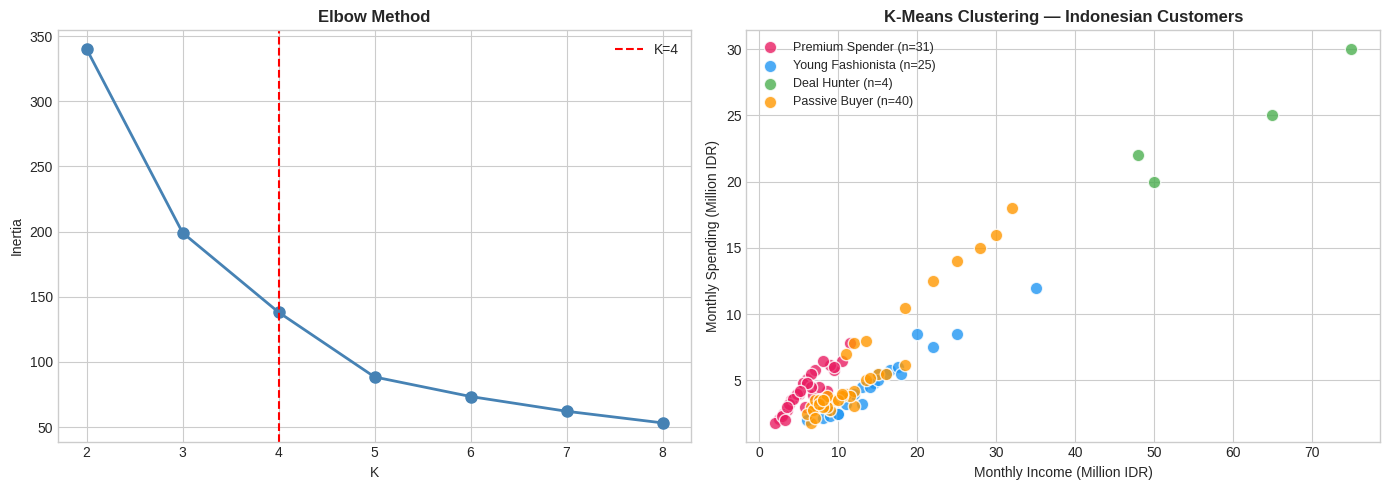


=== CLUSTER PROFILES ===
                   monthly_income_million_idr  monthly_spending_million_idr  shopping_frequency_per_month  loyalty_score    age
segment                                                                                                                        
Deal Hunter                             59.50                         24.25                          1.75          58.00  58.50
Passive Buyer                           12.25                          5.52                          7.68          78.15  32.75
Premium Spender                          5.86                          4.26                         17.06          89.26  24.39
Young Fashionista                       14.54                          4.80                          4.20          62.68  42.80


In [ ]:
features = df[['age', 'monthly_income_million_idr', 'monthly_spending_million_idr',
               'shopping_frequency_per_month', 'loyalty_score', 'recency_days']].copy()

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_ for k in range(2, 9)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2, 9), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', label='K=4')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

segment_names = {0: 'Premium Spender', 1: 'Young Fashionista', 2: 'Deal Hunter', 3: 'Passive Buyer'}
df['segment'] = df['kmeans_cluster'].map(segment_names)

colors = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']
for c_id in range(4):
    group = df[df['kmeans_cluster'] == c_id]
    axes[1].scatter(group['monthly_income_million_idr'], group['monthly_spending_million_idr'],
                    color=colors[c_id], alpha=0.8, edgecolors='white', s=80,
                    label=f'{segment_names[c_id]} (n={len(group)})')

axes[1].set_xlabel('Monthly Income (Million IDR)')
axes[1].set_ylabel('Monthly Spending (Million IDR)')
axes[1].set_title('K-Means Clustering — Indonesian Customers', fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CLUSTER PROFILES ===')
print(df.groupby('segment')[['monthly_income_million_idr', 'monthly_spending_million_idr',
                              'shopping_frequency_per_month', 'loyalty_score', 'age']].mean().round(2).to_string())

## 5. PCA 2D Visualization

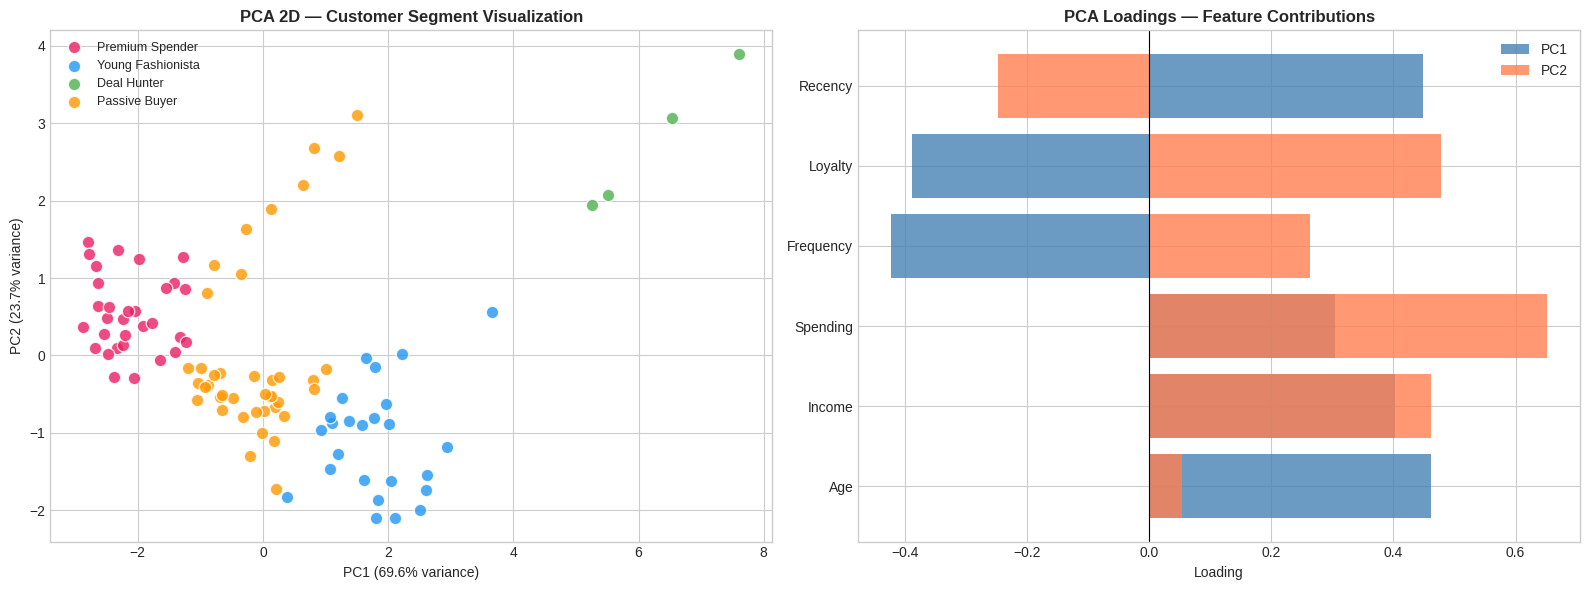

Total variance explained by 2 PCs: 93.4%


In [ ]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for c_id in range(4):
    mask = df['kmeans_cluster'] == c_id
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colors[c_id], alpha=0.8, edgecolors='white', s=80,
                    label=segment_names[c_id])

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('PCA 2D — Customer Segment Visualization', fontweight='bold')
axes[0].legend(fontsize=9)

feature_names = ['Age', 'Income', 'Spending', 'Frequency', 'Loyalty', 'Recency']
loadings = pca.components_.T
axes[1].barh(feature_names, loadings[:, 0], color='steelblue', alpha=0.8, label='PC1')
axes[1].barh(feature_names, loadings[:, 1], color='coral',     alpha=0.8, label='PC2')
axes[1].set_title('PCA Loadings — Feature Contributions', fontweight='bold')
axes[1].set_xlabel('Loading')
axes[1].legend()
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 6. Hierarchical Clustering + Dendrogram

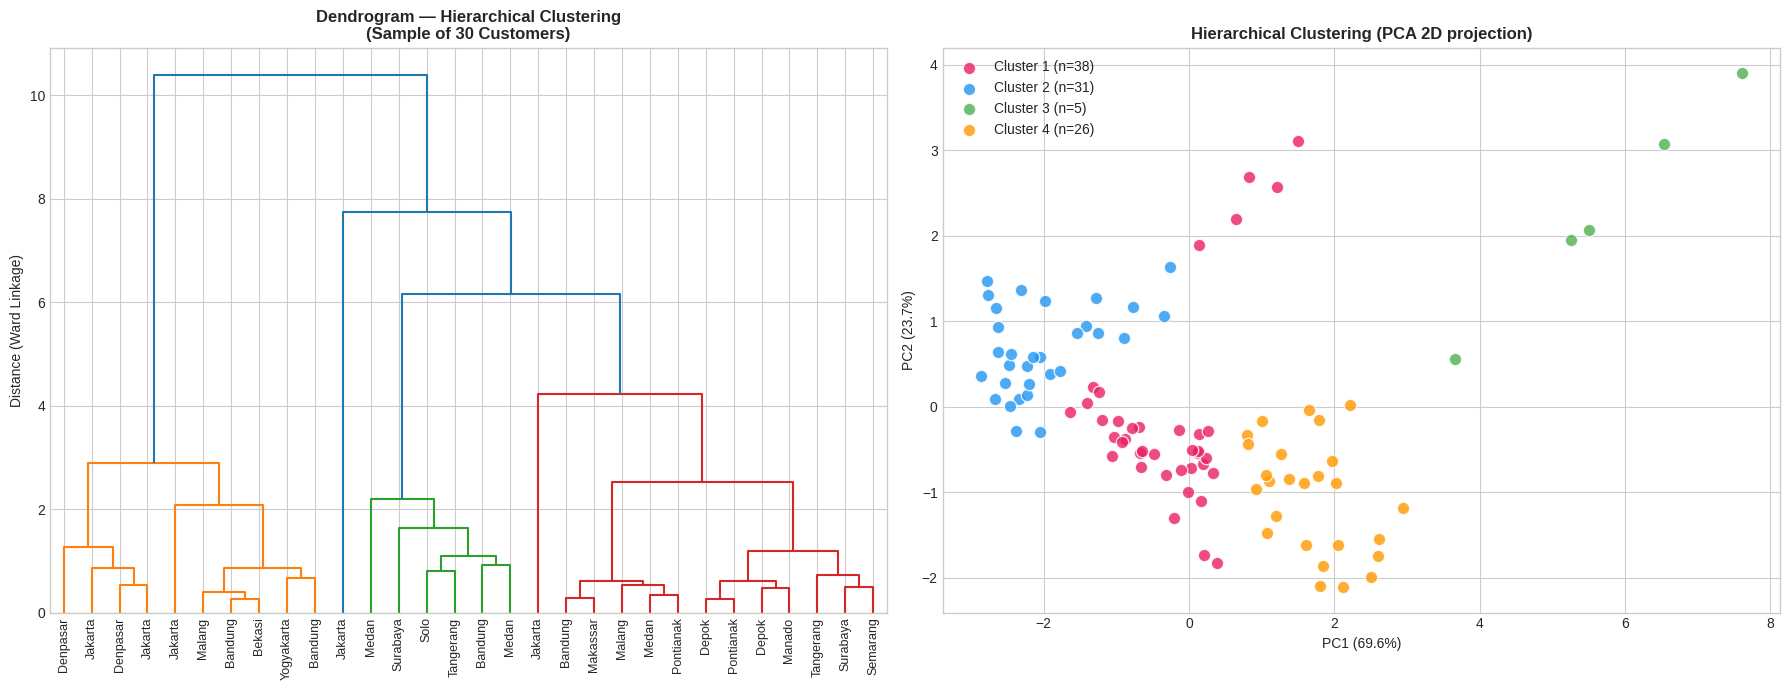

In [ ]:
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['hier_cluster'] = agg.fit_predict(X_scaled)

sample_idx    = np.random.choice(len(X_scaled), 30, replace=False)
X_sample      = X_scaled[sample_idx]
labels_sample = df.iloc[sample_idx]['city'].values
linkage_matrix = linkage(X_sample, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

dendrogram(linkage_matrix, labels=labels_sample, ax=axes[0],
           leaf_rotation=90, leaf_font_size=9, color_threshold=5)
axes[0].set_title('Dendrogram — Hierarchical Clustering\n(Sample of 30 Customers)', fontweight='bold')
axes[0].set_ylabel('Distance (Ward Linkage)')

for c_id in range(4):
    mask = df['hier_cluster'] == c_id
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colors[c_id], alpha=0.8, edgecolors='white', s=80,
                    label=f'Cluster {c_id+1} (n={mask.sum()})')

axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Hierarchical Clustering (PCA 2D projection)', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('hierarchical_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Segment Profiles & Marketing Recommendations

CUSTOMER SEGMENT PROFILES — INDONESIAN E-COMMERCE
                   Count  Avg_Age  Avg_Income  Avg_Spending  Avg_Frequency  Avg_Loyalty Top_City          Top_Category
segment                                                                                                               
Deal Hunter            4     58.5        59.5          24.2            1.8         58.0  Jakarta  Finance & Investment
Passive Buyer         40     32.8        12.2           5.5            7.7         78.2  Jakarta           Electronics
Premium Spender       31     24.4         5.9           4.3           17.1         89.3  Jakarta               Fashion
Young Fashionista     25     42.8        14.5           4.8            4.2         62.7    Medan        Food & Grocery

 MARKETING STRATEGY RECOMMENDATIONS:
  Premium Spender    → VIP programs, exclusive products, personal shopping assistants
  Young Fashionista  → Flash sales, influencer campaigns, mobile-first UX
  Deal Hunter        → Discount vouche

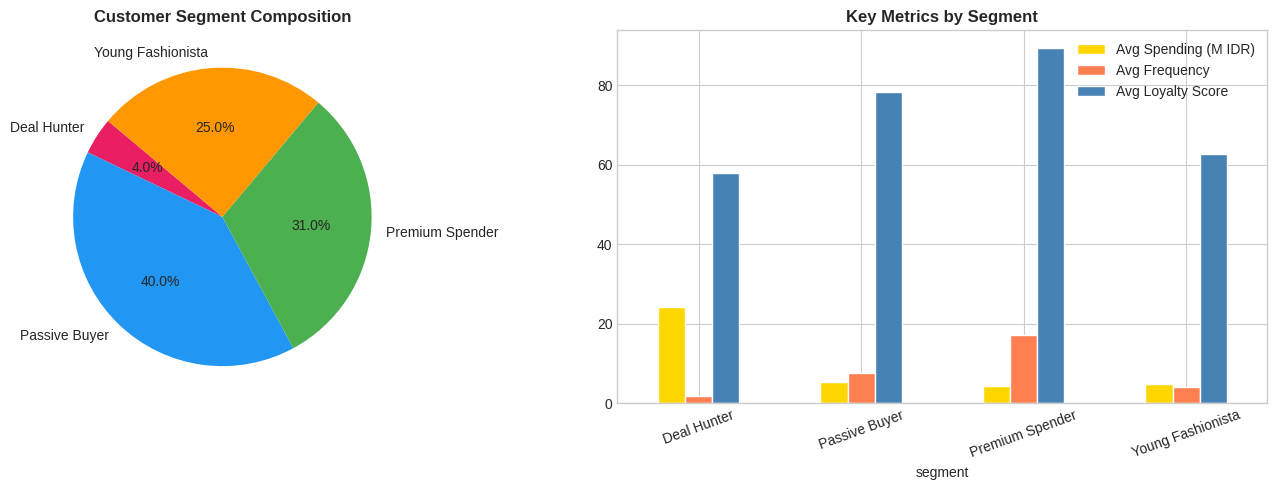


All analysis complete. Output charts saved to data/


In [ ]:
print('=' * 70)
print('CUSTOMER SEGMENT PROFILES — INDONESIAN E-COMMERCE')
print('=' * 70)

profile = df.groupby('segment').agg(
    Count              =('customer_id', 'count'),
    Avg_Age            =('age', 'mean'),
    Avg_Income         =('monthly_income_million_idr', 'mean'),
    Avg_Spending       =('monthly_spending_million_idr', 'mean'),
    Avg_Frequency      =('shopping_frequency_per_month', 'mean'),
    Avg_Loyalty        =('loyalty_score', 'mean'),
    Top_City           =('city', lambda x: x.value_counts().index[0]),
    Top_Category       =('favorite_product_category', lambda x: x.value_counts().index[0])
).round(1)

print(profile.to_string())

print('\n MARKETING STRATEGY RECOMMENDATIONS:')
print('  Premium Spender    → VIP programs, exclusive products, personal shopping assistants')
print('  Young Fashionista  → Flash sales, influencer campaigns, mobile-first UX')
print('  Deal Hunter        → Discount vouchers, product bundles, referral programs')
print('  Passive Buyer      → Re-engagement emails, push notifications, exclusive win-back offers')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
profile['Count'].plot(kind='pie', ax=axes[0], colors=colors,
                      autopct='%1.1f%%', startangle=140)
axes[0].set_title('Customer Segment Composition', fontweight='bold')
axes[0].set_ylabel('')

profile[['Avg_Spending', 'Avg_Frequency', 'Avg_Loyalty']].plot(
    kind='bar', ax=axes[1], color=['gold', 'coral', 'steelblue'], edgecolor='white')
axes[1].set_title('Key Metrics by Segment', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(['Avg Spending (M IDR)', 'Avg Frequency', 'Avg Loyalty Score'])

plt.tight_layout()
plt.savefig('segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll analysis complete. Output charts saved to data/')